In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings('ignore') # Ocultar advertencias de Pandas/Scikit-Learn

def procesar_predicciones(csv_path, cols, model_path, scaler_path, titulo_graficas):
    """Función base para cargar modelo, predecir en lote y graficar"""
    print(f"Cargando datos desde: {csv_path}")
    df = pd.read_csv(csv_path)
    
    # Limpieza de fechas
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed', errors='coerce')
    df = df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
    
    # Cargar Modelos
    try:
        model = load_model(model_path)
        scaler = joblib.load(scaler_path)
    except Exception as e:
        print(f"Error al cargar el modelo o escalador. ¿Están en la ruta correcta?: {e}")
        return
    
    # Escalar datos
    data = df[cols].values
    scaled_data = scaler.transform(data)
    
    LOOK_BACK = 30
    STEP_AHEAD = 3
    
    # Preparar el lote de datos (Batch) para hacerlo muy rápido
    X_batch = []
    fechas_reales = df['Date'].values
    fechas_prediccion = []
    
    for i in range(len(scaled_data) - LOOK_BACK):
        X_batch.append(scaled_data[i : i + LOOK_BACK])
        
        # Calcular a qué hora corresponde la predicción (+3 minutos en el futuro)
        idx_futuro = i + LOOK_BACK + STEP_AHEAD - 1
        if idx_futuro < len(fechas_reales):
            fechas_prediccion.append(fechas_reales[idx_futuro])
        else:
            # Si se acaba el dataset, extrapolamos el tiempo
            fechas_prediccion.append(fechas_reales[-1] + np.timedelta64(STEP_AHEAD, 'm'))
            
    X_batch = np.array(X_batch)
    
    print("Generando predicciones con Inteligencia Artificial...")
    # Predicción del cambio (Delta) de golpe
    deltas = model.predict(X_batch, batch_size=128, verbose=0)
    
    # Sumar el delta al último valor conocido de la ventana
    last_known_scaled = X_batch[:, -1, :] 
    future_scaled = last_known_scaled + deltas
    
    # Desescalar a grados/porcentajes reales
    predicciones_reales = scaler.inverse_transform(future_scaled)
    
    # Graficar
    print("Dibujando resultados...")
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle(f'Resultados IA: Real vs Predicción (+3 min) - {titulo_graficas}', fontsize=16, fontweight='bold')
    
    for i, col in enumerate(cols):
        ax = axes[i//2, i%2]
        
        # Graficamos la línea real a partir del registro 30 (donde empieza a predecir)
        ax.plot(fechas_reales[LOOK_BACK:], df[col].iloc[LOOK_BACK:], label=f'{col.upper()} (Real)', color='#0ea5e9', linewidth=1.5)
        
        # Graficamos la predicción alineada a sus fechas
        ax.plot(fechas_prediccion, predicciones_reales[:, i], label='Predicción (+3m)', color='#ef4444', linestyle='--', linewidth=1.5, alpha=0.8)
        
        ax.set_title(f'Sensor: {col.upper()}', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylabel('Valor')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()


# ==========================================
# FUNCIONES PARA EL EQUIPO de SPACE
# ==========================================

def prediccion_temperaturas(archivo_csv):
    """Analiza y grafica un CSV con datos de Temperatura"""
    procesar_predicciones(
        csv_path = archivo_csv,
        cols = ['t1', 't2', 't3', 't4', 't5', 'tex'],
        model_path = 'models/model_t.keras',
        scaler_path = 'models/scaler_t.save',
        titulo_graficas = 'Temperaturas'
    )

def prediccion_humedades(archivo_csv):
    """Analiza y grafica un CSV con datos de Humedad"""
    procesar_predicciones(
        csv_path = archivo_csv,
        cols = ['h1', 'h2', 'h3', 'h4', 'h5', 'hex'],
        model_path = 'models/model_h.keras',
        scaler_path = 'models/scaler_h.save',
        titulo_graficas = 'Humedades'
    )

Cargando datos desde: DATASET_TEMPERATURA.csv
Generando predicciones con Inteligencia Artificial...
Dibujando resultados...


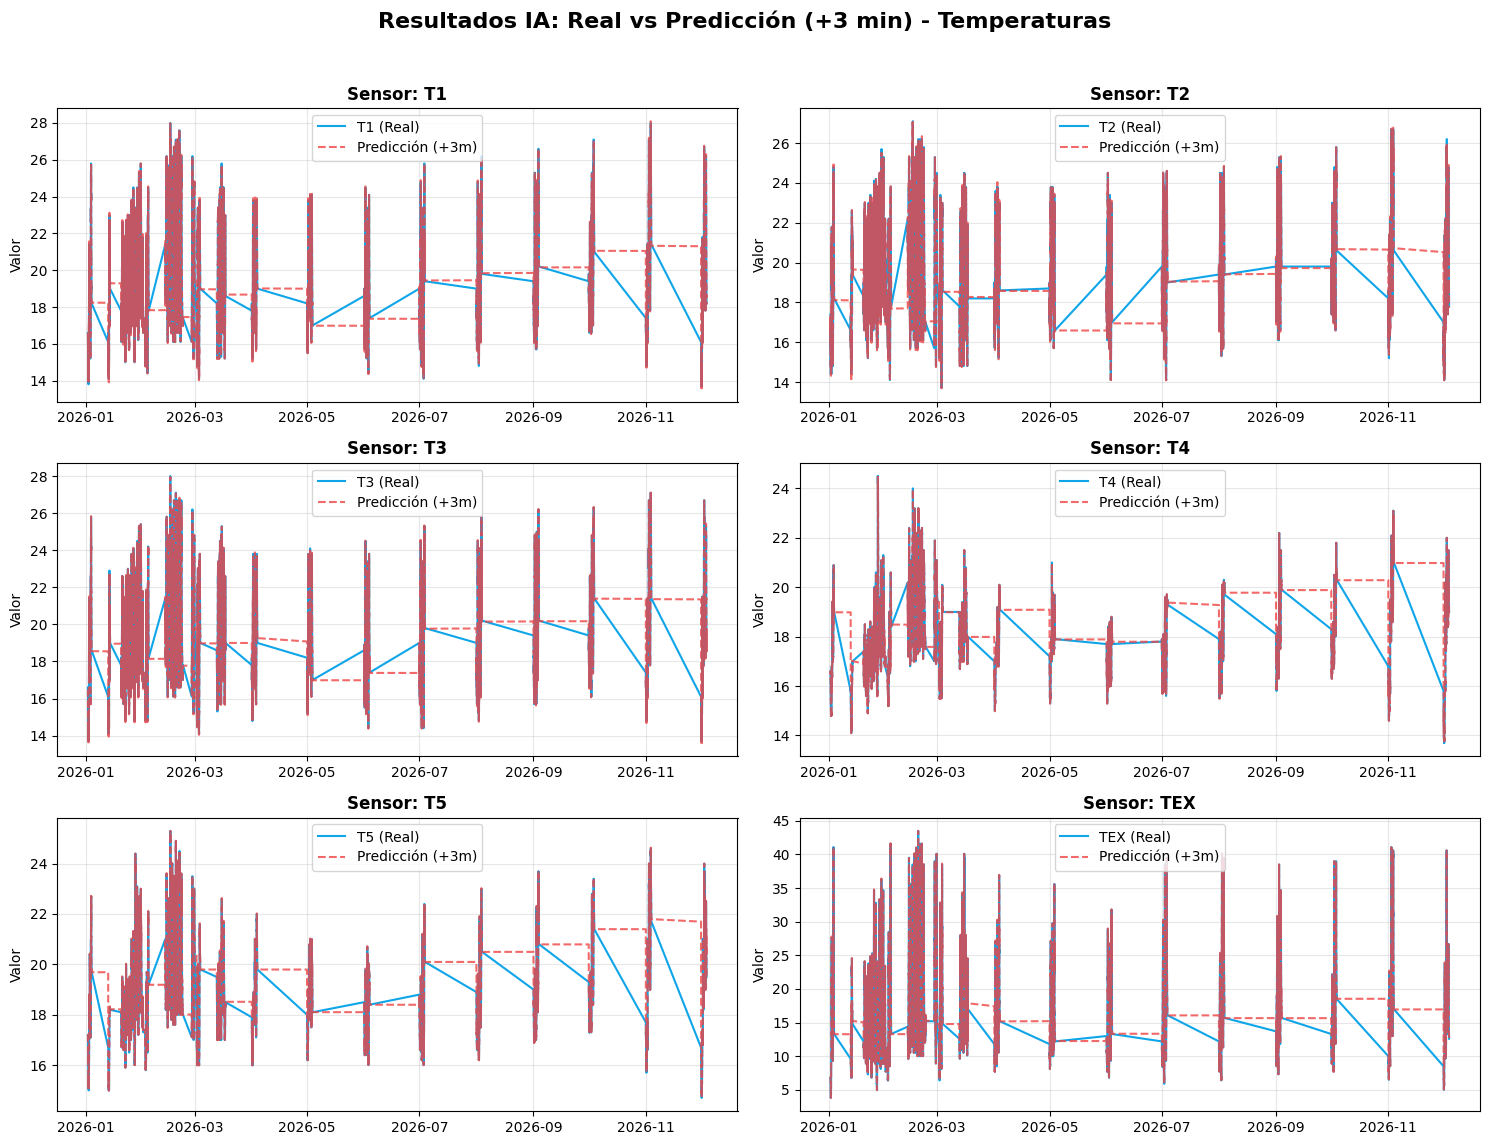

Cargando datos desde: DATASET_HUMEDAD.csv
Generando predicciones con Inteligencia Artificial...
Dibujando resultados...


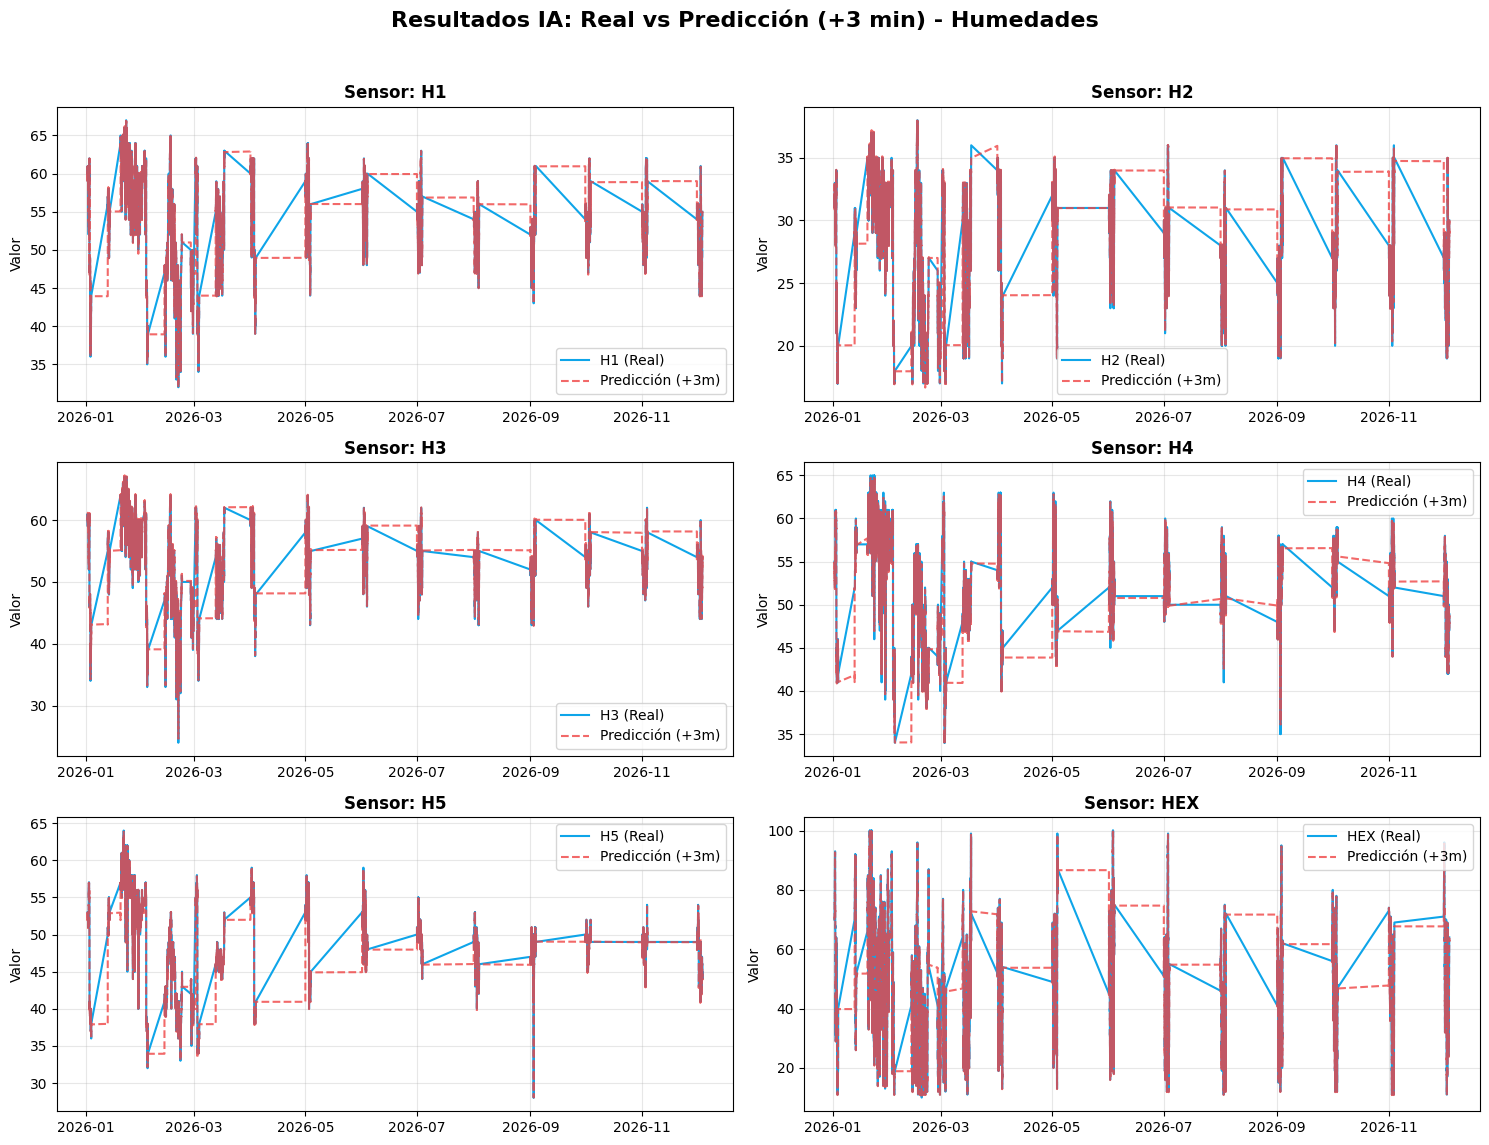

In [3]:
# Analizar el archivo de temperaturas
prediccion_temperaturas("DATASET_TEMPERATURA.csv")

# Analizar el archivo de humedades
prediccion_humedades("DATASET_HUMEDAD.csv")